In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.59G/2.59G [02:06<00:00, 22.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2
Contents of base_path (/root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions):
['2']
Contents of path (/root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2):
['GroundTruth.csv', 'images', 'masks']


Checking for images in: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images

Found 10015 image files in total. Displaying samples:


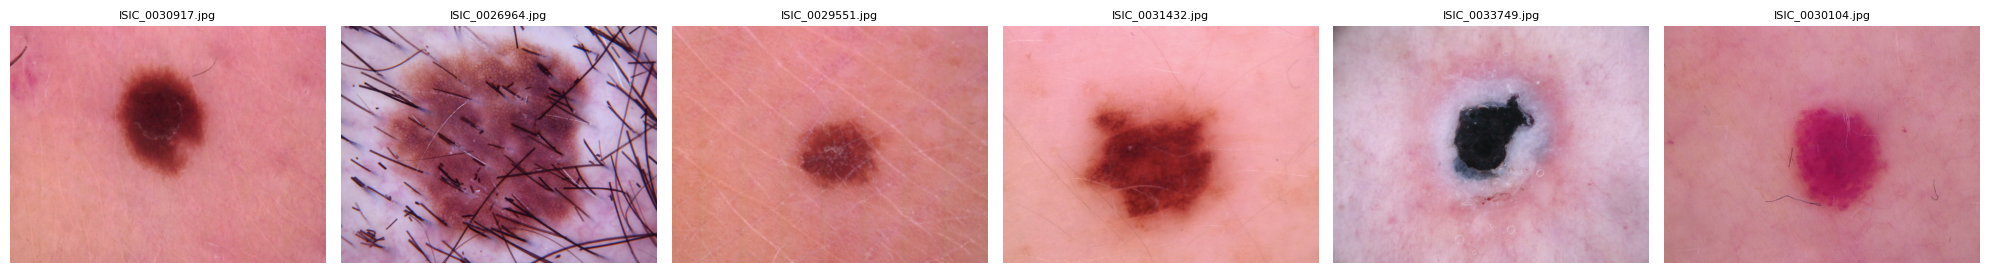

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the root directory containing the images
image_root_dir = os.path.join(path, 'images')

print(f"Checking for images in: {image_root_dir}")
if not os.path.exists(image_root_dir):
    print(f"Error: Directory '{image_root_dir}' not found.")
else:
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    # Scan through the images folder directly
    for root, dirs, files in os.walk(image_root_dir):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if all_image_paths:
        print(f"\nFound {len(all_image_paths)} image files in total. Displaying samples:")

        # Select up to 6 samples to display
        num_samples = min(len(all_image_paths), 6)
        samples_to_display = all_image_paths[:num_samples]

        fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
        if num_samples == 1:
            axes = [axes]

        for i, img_path in enumerate(samples_to_display):
            try:
                img = Image.open(img_path)
                axes[i].imshow(img)
                # Show the filename
                axes[i].set_title(os.path.basename(img_path), fontsize=8)
                axes[i].axis('off')
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo images found in the 'images' folder.")

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# Path to the metadata file containing labels
metadata_path = os.path.join(path, 'GroundTruth.csv')

if os.path.exists(metadata_path):
    # Read data from CSV file
    df = pd.read_csv(metadata_path)

    # Split dataset into train (80%) and test (20%)
    # random_state=42 ensures reproducibility
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

    print(f"Total samples: {len(df)}")
    print(f"Training set size: {len(train_df)} (80%)")
    print(f"Testing set size: {len(test_df)} (20%)")

    # Display first few rows of the training set
    display(train_df.head())
else:
    # If no metadata file exists, split based on image paths
    train_paths, test_paths = train_test_split(all_image_paths, test_size=0.2, random_state=42)
    print(f"GroundTruth.csv not found. Splitting directly from image file list:")
    print(f"Training image count: {len(train_paths)}")
    print(f"Testing image count: {len(test_paths)}")

Total samples: 10015
Training set size: 8012 (80%)
Testing set size: 2003 (20%)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
6582,ISIC_0030888,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7194,ISIC_0031500,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9446,ISIC_0033752,1.0,0.0,0.0,0.0,0.0,0.0,0.0
533,ISIC_0024839,0.0,0.0,0.0,0.0,1.0,0.0,0.0
132,ISIC_0024438,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import torch

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

# Custom Dataset for HAM10000
class HAM1000Dataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform
        # Labels are the columns from index 1 onwards in GroundTruth.csv
        self.labels = self.df.iloc[:, 1:].values.argmax(axis=1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.df.iloc[idx, 0] + '.jpg')
        image = Image.open(img_name).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Prepare DataLoaders
train_dataset = HAM1000Dataset(train_df, image_root_dir, transform=transform)
test_dataset = HAM1000Dataset(test_df, image_root_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Build DenseNet Model
model = models.densenet121(weights='IMAGENET1K_V1')
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 7) # 7 classes in HAM10000
model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
history = {'train_loss': [], 'test_acc': []}
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)

    # Simple Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    history['test_acc'].append(accuracy)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.2f}%')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 103MB/s]


Epoch 1/10, Loss: 0.6680, Accuracy: 82.13%
Epoch 2/10, Loss: 0.3307, Accuracy: 83.52%
Epoch 3/10, Loss: 0.1693, Accuracy: 86.42%
Epoch 4/10, Loss: 0.0978, Accuracy: 85.12%
Epoch 5/10, Loss: 0.0764, Accuracy: 85.47%
Epoch 6/10, Loss: 0.0648, Accuracy: 87.12%
Epoch 7/10, Loss: 0.0411, Accuracy: 86.62%
Epoch 8/10, Loss: 0.0398, Accuracy: 87.57%
Epoch 9/10, Loss: 0.0378, Accuracy: 85.07%
Epoch 10/10, Loss: 0.0427, Accuracy: 87.12%


In [ ]:
print("--- Training Summary ---")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"Best Test Accuracy: {max(history['test_acc']):.2f}%")

--- Training Summary ---
Final Training Loss: 0.0427
Final Test Accuracy: 87.12%
Best Test Accuracy: 87.57%


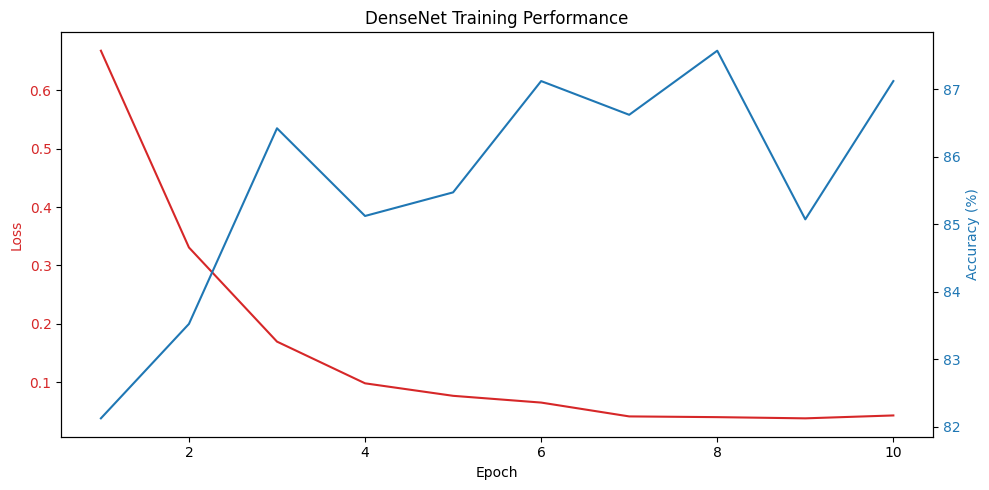

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(range(1, epochs + 1), history['train_loss'], color='tab:red', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (%)', color='tab:blue')
ax2.plot(range(1, epochs + 1), history['test_acc'], color='tab:blue', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('DenseNet Training Performance')
fig.tight_layout()
plt.show()